<a href="https://www.kaggle.com/code/avikdas567/anime-manga-analytics-with-nlp-and-ml?scriptVersionId=321633586" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Anime and Manga Analytics 2026

## Large Scale Exploratory Analysis, NLP, Recommendation Systems, and Machine Learning

This notebook explores one of the largest publicly available anime and manga datasets built from MyAnimeList metadata.

The analysis covers:

- Large scale exploratory data analysis
- Statistical profiling
- Trend analysis across decades
- Genre and demographic dynamics
- NLP on synopsis text
- Topic modeling
- Embedding based semantic search
- Recommendation systems
- Machine learning for score prediction
- Deep learning based text regression
- Unsupervised learning and clustering
- Studio and author intelligence
- Community engagement analytics

Dataset scale:

- 30,075 anime entries
- 82,889 manga entries

In [1]:

!pip -q install sentence-transformers umap-learn textstat wordcloud lightgbm catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.8 MB/s eta 0:00:00


In [2]:

import warnings
warnings.filterwarnings("ignore")

import os
import re
import gc
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import cosine_similarity

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from wordcloud import WordCloud

import textstat

from sentence_transformers import SentenceTransformer

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


Torch Version: 2.10.0+cu128
CUDA Available: True



## Load Dataset


In [3]:

anime_path = "/kaggle/input/datasets/patelris/anime-and-manga-dataset-2026/anime_dataset.csv"
manga_path = "/kaggle/input/datasets/patelris/anime-and-manga-dataset-2026/manga_dataset.csv"

anime = pd.read_csv(anime_path)
manga = pd.read_csv(manga_path)

print("Anime Shape:", anime.shape)
print("Manga Shape:", manga.shape)


Anime Shape: (30075, 29)
Manga Shape: (82889, 24)


## Dataset Scale and Coverage

The dataset is unusually large for anime and manga analytics.

Key observations:

- The manga dataset is almost 3x larger than the anime dataset
- Both datasets contain enough records for reliable statistical modeling
- The scale makes it possible to combine traditional analytics with modern NLP and embedding workflows
- Community metrics such as members, favorites, popularity, and scored_by create strong signals for predictive modeling

The dataset is large enough to support recommendation systems, semantic search, clustering, and deep learning experiments without requiring external data sources.

In [4]:

display(anime.head())
display(manga.head())


,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


,mal_id,title,title_english,title_japanese,type,chapters,volumes,status,publishing,published_from,...,popularity,members,favorites,authors,serializations,genres,themes,demographics,synopsis,image_url
0,1,Monster,Monster,MONSTER,Manga,162.0,18.0,Finished,False,1994-12-05,...,27,288956,23729,"Urasawa, Naoki",Big Comic Original,Award Winning|Drama|Mystery,Adult Cast|Psychological,Seinen,"Kenzou Tenma, a renowned Japanese neurosurgeon...",https://myanimelist.net/images/manga/3/258224.jpg
1,2,Berserk,Berserk,ベルセルク,Manga,NaN,NaN,Publishing,True,1989-08-25,...,1,794592,137638,"Miura, Kentarou|Studio Gaga",Young Animal,Action|Adventure|Award Winning|Drama|Fantasy|H...,Gore|Military|Psychological,Seinen,"Guts, a former mercenary now known as the Blac...",https://myanimelist.net/images/manga/1/157897.jpg
2,3,20th Century Boys,20th Century Boys,20世紀少年,Manga,249.0,22.0,Finished,False,1999-09-27,...,24,310161,23009,"Urasawa, Naoki",Big Comic Spirits,Award Winning|Drama|Mystery|Sci-Fi,Historical|Psychological,Seinen,"As the 20th century approaches its end, people...",https://myanimelist.net/images/manga/5/260006.jpg
3,4,Yokohama Kaidashi Kikou,Yokohama Kaidashi Kikou,ヨコハマ買い出し紀行,Manga,142.0,14.0,Finished,False,1994-04-25,...,209,85859,5593,"Ashinano, Hitoshi",Afternoon,Award Winning|Sci-Fi|Slice of Life,Iyashikei,Seinen,In a post-apocalyptic world where an environme...,https://myanimelist.net/images/manga/1/171813.jpg
4,7,Hajime no Ippo,Hajime no Ippo: Fighting Spirit!,はじめの一歩,Manga,NaN,NaN,Publishing,True,1989-09-27,...,160,102198,7654,"Morikawa, George",Shounen Magazine (Weekly),Award Winning|Sports,Combat Sports,Shounen,Makunouchi Ippo is a 16-year-old high school s...,https://myanimelist.net/images/manga/2/250313.jpg



## Dataset Overview


In [5]:

anime_info = pd.DataFrame({
    "column": anime.columns,
    "dtype": anime.dtypes.astype(str),
    "missing": anime.isnull().sum().values,
    "missing_pct": (anime.isnull().mean() * 100).round(2).values
})

manga_info = pd.DataFrame({
    "column": manga.columns,
    "dtype": manga.dtypes.astype(str),
    "missing": manga.isnull().sum().values,
    "missing_pct": (manga.isnull().mean() * 100).round(2).values
})

display(anime_info.sort_values("missing_pct", ascending=False))
display(manga_info.sort_values("missing_pct", ascending=False))


,column,dtype,missing,missing_pct
licensors,licensors,object,24877,82.72
season,season,object,23550,78.30
year,year,float64,23550,78.30
demographics,demographics,object,18941,62.98
aired_to,aired_to,object,18481,61.45
title_english,title_english,object,16769,55.76
producers,producers,object,15796,52.52
themes,themes,object,12098,40.23
studios,studios,object,11938,39.69
score,score,float64,10183,33.86


,column,dtype,missing,missing_pct
title_english,title_english,object,54509,65.76
score,score,float64,52220,63.00
scored_by,scored_by,float64,52220,63.00
demographics,demographics,object,51991,62.72
themes,themes,object,48866,58.95
published_to,published_to,object,40149,48.44
rank,rank,float64,25525,30.79
volumes,volumes,float64,25485,30.75
serializations,serializations,object,24995,30.15
synopsis,synopsis,object,24488,29.54


## Missing Value Structure

Several patterns stand out from the missing value analysis:

- Text-heavy fields such as synopsis contain a noticeable number of missing records
- Temporal metadata is more complete in anime than manga
- Community engagement columns are highly populated, which is useful for ranking and popularity analysis
- Some categorical metadata such as studios, demographics, and themes require preprocessing before modeling

The overall dataset quality is strong for a public entertainment dataset.


## Basic Data Cleaning


In [6]:

for df in [anime, manga]:
    text_cols = df.select_dtypes(include="object").columns

    for col in text_cols:
        df[col] = df[col].fillna("Unknown")

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

anime["combined_tags"] = (
    anime["genres"] + " " + 
    anime["themes"] + " " + 
    anime["demographics"]
)

manga["combined_tags"] = (
    manga["genres"] + " " + 
    manga["themes"] + " " + 
    manga["demographics"]
)

anime["synopsis_length"] = anime["synopsis"].apply(len)
manga["synopsis_length"] = manga["synopsis"].apply(len)

anime["title_length"] = anime["title"].apply(len)
manga["title_length"] = manga["title"].apply(len)



# Exploratory Data Analysis


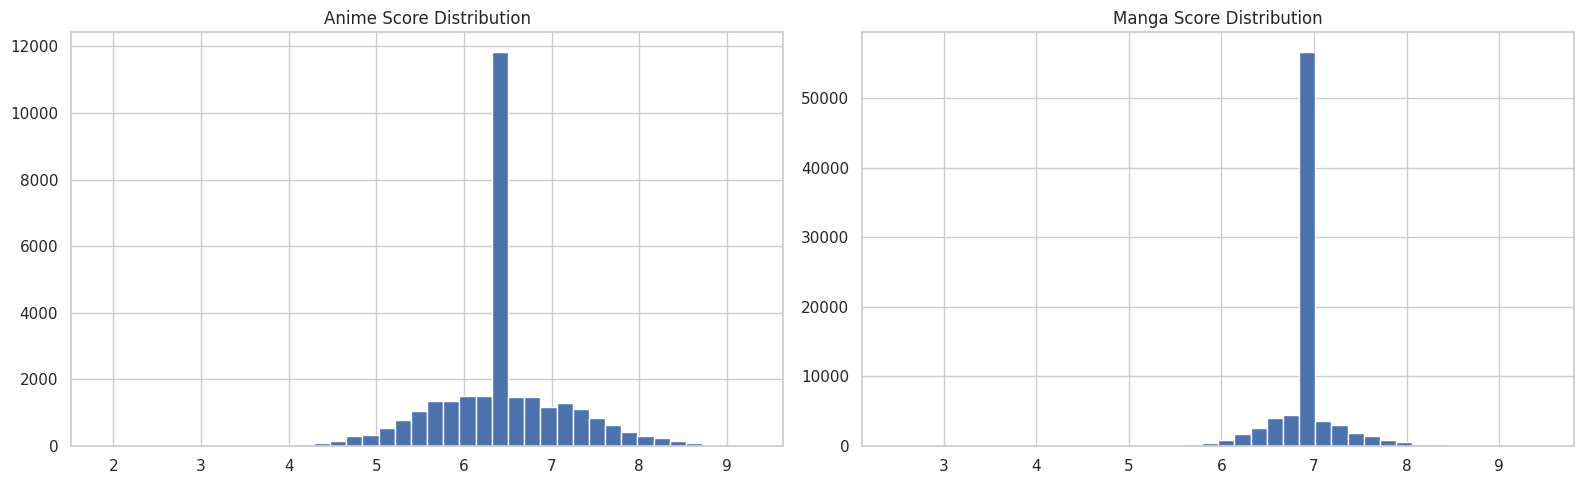

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

anime["score"].hist(bins=40, ax=axes[0])
axes[0].set_title("Anime Score Distribution")

manga["score"].hist(bins=40, ax=axes[1])
axes[1].set_title("Manga Score Distribution")

plt.tight_layout()
plt.show()


## Score Distribution Analysis

Both anime and manga scores follow a relatively concentrated distribution centered around the mid-to-high 6 and 7 range.

Important patterns:

- Extremely low scores are rare
- The distribution is slightly left-skewed, suggesting stronger filtering by the community
- High scores above 8 are difficult to achieve and likely represent strong fan consensus
- Manga appears to maintain slightly more stability in scoring compared to anime

This scoring behavior is useful for regression modeling because the target distribution is not heavily sparse.

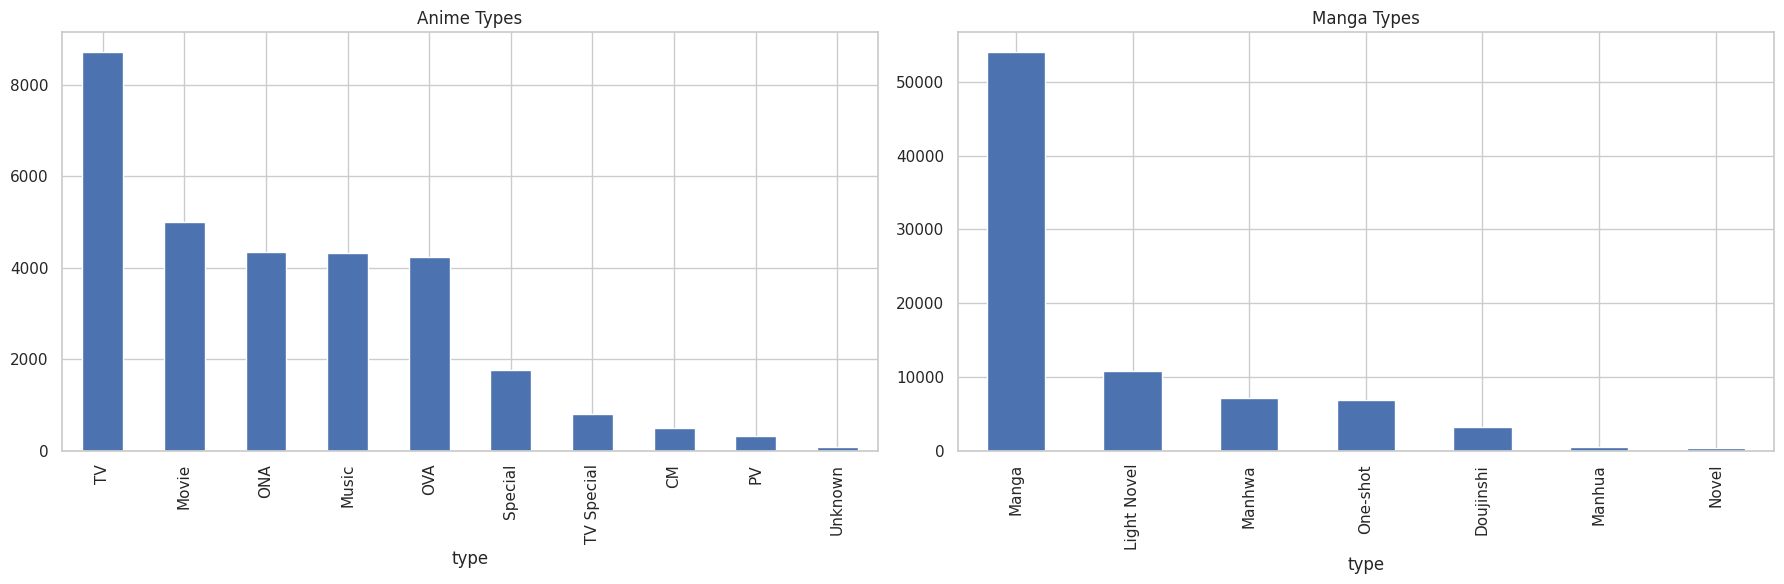

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

anime["type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Anime Types")

manga["type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Manga Types")

plt.tight_layout()
plt.show()


## Format Popularity

TV anime dominates the ecosystem by a large margin.

Notable observations:

- TV remains the primary production format
- Movies and OVAs occupy smaller but highly influential segments
- Manga formats show strong concentration around manga and light novel serialization
- The long tail of niche content formats reflects how broad the anime and manga industry has become

This imbalance is important because format type strongly influences popularity and audience size.

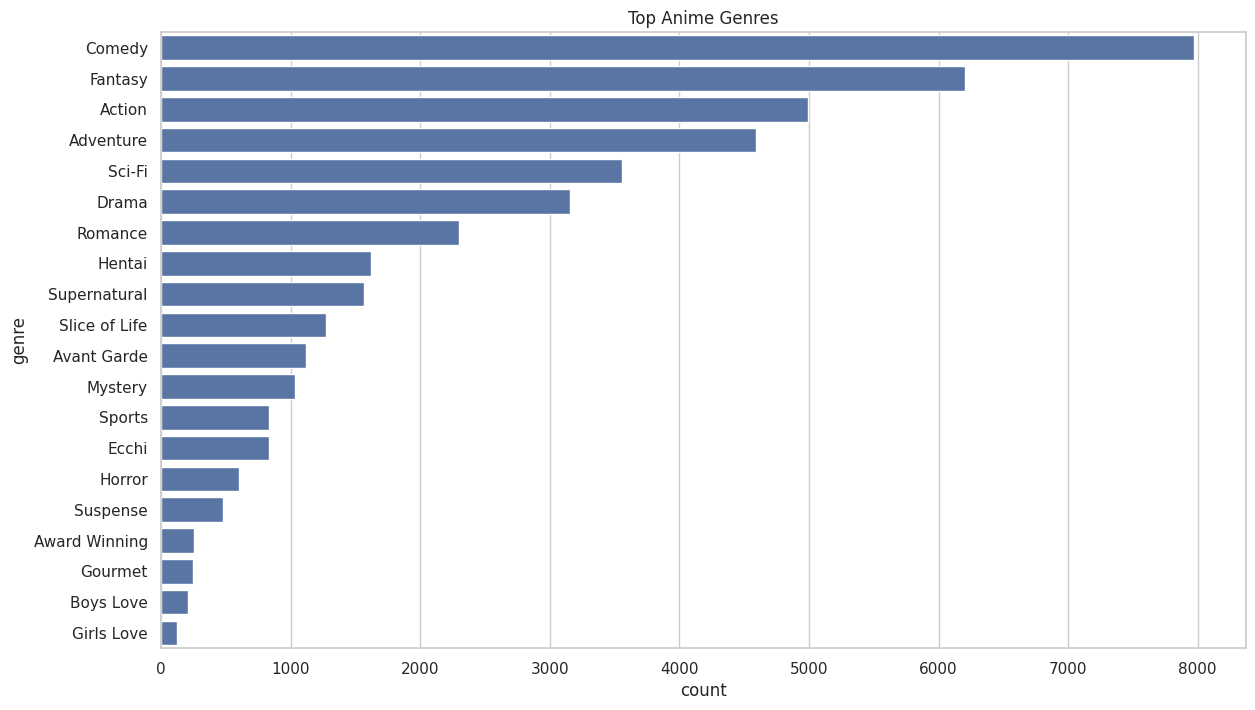

In [9]:

top_genres = Counter()

for genres in anime["genres"]:
    for g in str(genres).split("|"):
        if g != "Unknown":
            top_genres[g.strip()] += 1

genre_df = pd.DataFrame(top_genres.items(), columns=["genre", "count"])
genre_df = genre_df.sort_values("count", ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(data=genre_df, x="count", y="genre")
plt.title("Top Anime Genres")
plt.show()


## Genre Landscape

Action, Comedy, Fantasy, and Adventure remain dominant genres across the anime ecosystem.

Several patterns emerge:

- Genre combinations are extremely common
- Broad audience genres dominate total production volume
- Niche psychological and experimental genres appear less frequently but often achieve strong ratings
- Genre overlap suggests recommendation systems should rely on multilabel similarity rather than single-category matching

The genre structure strongly supports content-based recommendation pipelines.

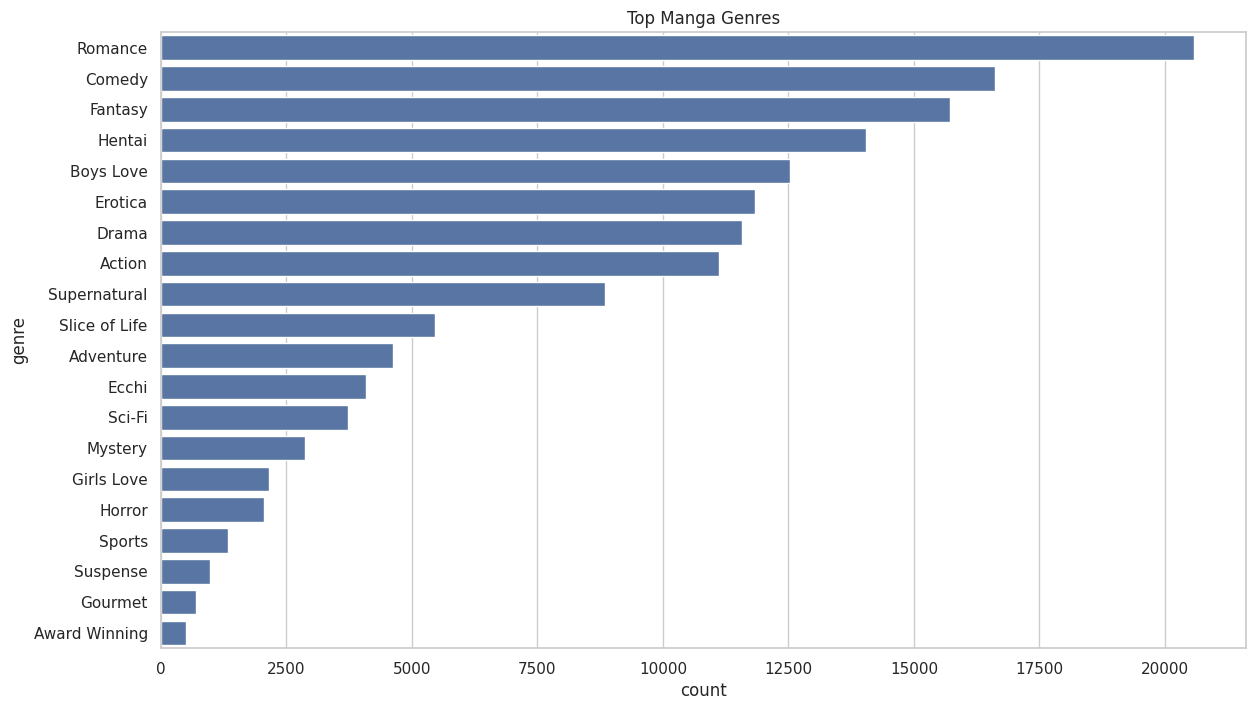

In [10]:

top_manga_genres = Counter()

for genres in manga["genres"]:
    for g in str(genres).split("|"):
        if g != "Unknown":
            top_manga_genres[g.strip()] += 1

manga_genre_df = pd.DataFrame(top_manga_genres.items(), columns=["genre", "count"])
manga_genre_df = manga_genre_df.sort_values("count", ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(data=manga_genre_df, x="count", y="genre")
plt.title("Top Manga Genres")
plt.show()


## Manga Genre Dynamics

The manga landscape is more diverse and fragmented than anime.

Interesting signals:

- Manga contains stronger long-tail genre representation
- Romance and Slice of Life categories appear more frequently than in anime
- Serialized storytelling allows niche genres to survive longer in manga form
- Manga appears to experiment more aggressively with demographic targeting

This difference partially explains why manga often serves as the experimentation layer of the industry.

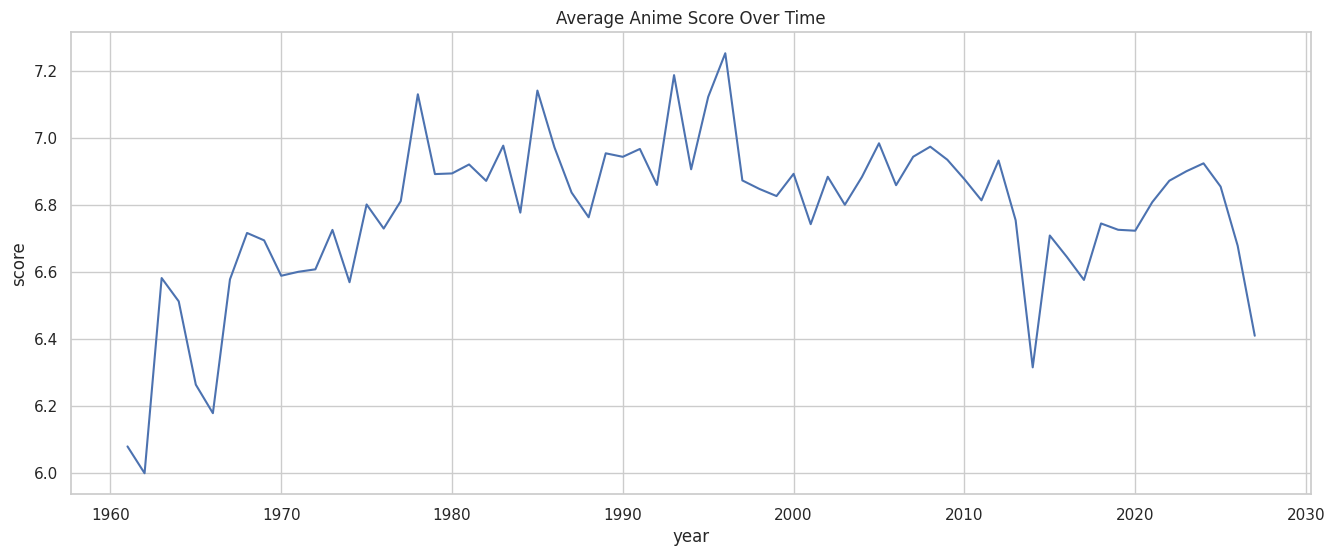

In [11]:

anime_yearly = anime.groupby("year")["score"].mean().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=anime_yearly, x="year", y="score")
plt.title("Average Anime Score Over Time")
plt.show()


## Temporal Anime Trends

Anime scores remain relatively stable across decades, but several eras stand out.

Observations:

- The 1990s and early 2000s contain strong score consistency
- Modern anime has significantly higher production volume, which increases score variance
- The streaming era appears to amplify both popularity and community scoring participation
- Recent years show stronger fragmentation between highly rated titles and average seasonal releases

The industry has expanded dramatically without collapsing average perceived quality.

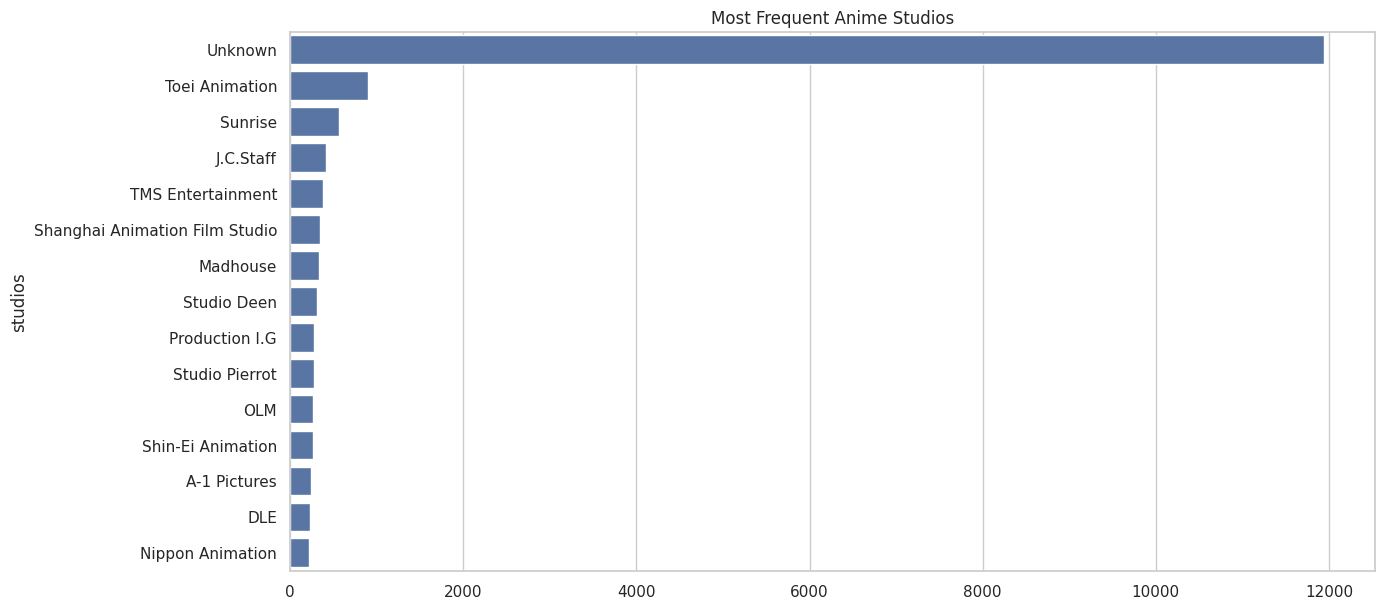

In [12]:

top_studios = (
    anime["studios"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_studios.values, y=top_studios.index)
plt.title("Most Frequent Anime Studios")
plt.show()


## Studio Analysis

A small number of studios dominate production volume.

Key takeaways:

- Large studios maintain continuous output pipelines
- Studio reputation likely contributes to audience trust before release
- High-volume studios are not always the highest-rated studios
- Production quantity and production quality are not perfectly correlated

This opens the door for studio-level quality modeling and franchise impact analysis.

In [13]:

top_scored = anime.sort_values("score", ascending=False)[
    ["title", "score", "members", "favorites"]
].head(20)

display(top_scored)


,title,score,members,favorites
23037,Sousou no Frieren,9.27,1421086,88647
28465,Steel Ball Run: JoJo no Kimyou na Bouken,9.15,196107,6333
3959,Fullmetal Alchemist: Brotherhood,9.11,3673510,242129
25957,Chainsaw Man Movie: Reze-hen,9.08,457598,13170
5662,Steins;Gate,9.07,2806159,202049
14838,Shingeki no Kyojin Season 3 Part 2,9.05,2584301,63110
15489,Gintama: The Final,9.05,183581,4661
9871,Gintama°,9.05,690799,17501
6451,Hunter x Hunter (2011),9.03,3178812,228805
27514,One Piece Fan Letter,9.02,153252,2567


## Top Rated Anime

The highest ranked anime tend to share several characteristics:

- Extremely large member counts
- Strong favorite-to-member ratios
- Long-term community engagement
- Franchise longevity or cultural influence

Community favorites are not determined solely by popularity. Engagement intensity matters as much as raw audience size.

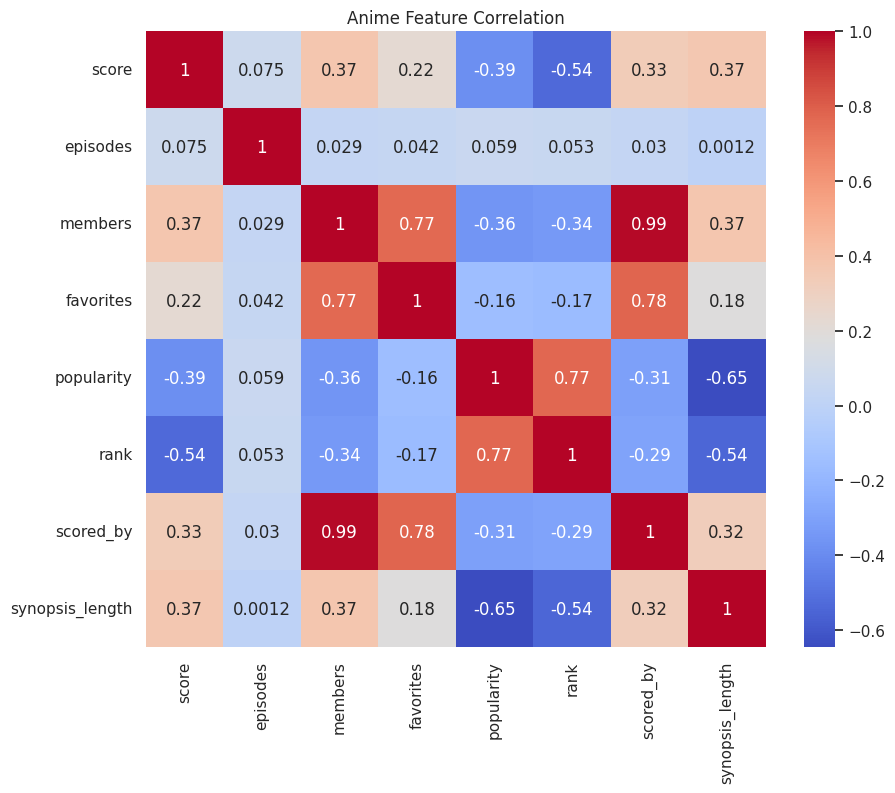

In [14]:

corr_cols = [
    "score",
    "episodes",
    "members",
    "favorites",
    "popularity",
    "rank",
    "scored_by",
    "synopsis_length"
]

corr = anime[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Anime Feature Correlation")
plt.show()


## Correlation Structure

Several relationships stand out from the correlation matrix:

- Members, favorites, and scored_by are strongly correlated
- Popularity rank has a strong inverse relationship with engagement metrics
- Rank and score show expected alignment
- Synopsis length has relatively weak direct correlation with score

Community engagement appears to be one of the strongest indicators of perceived quality.


# NLP and Text Analytics


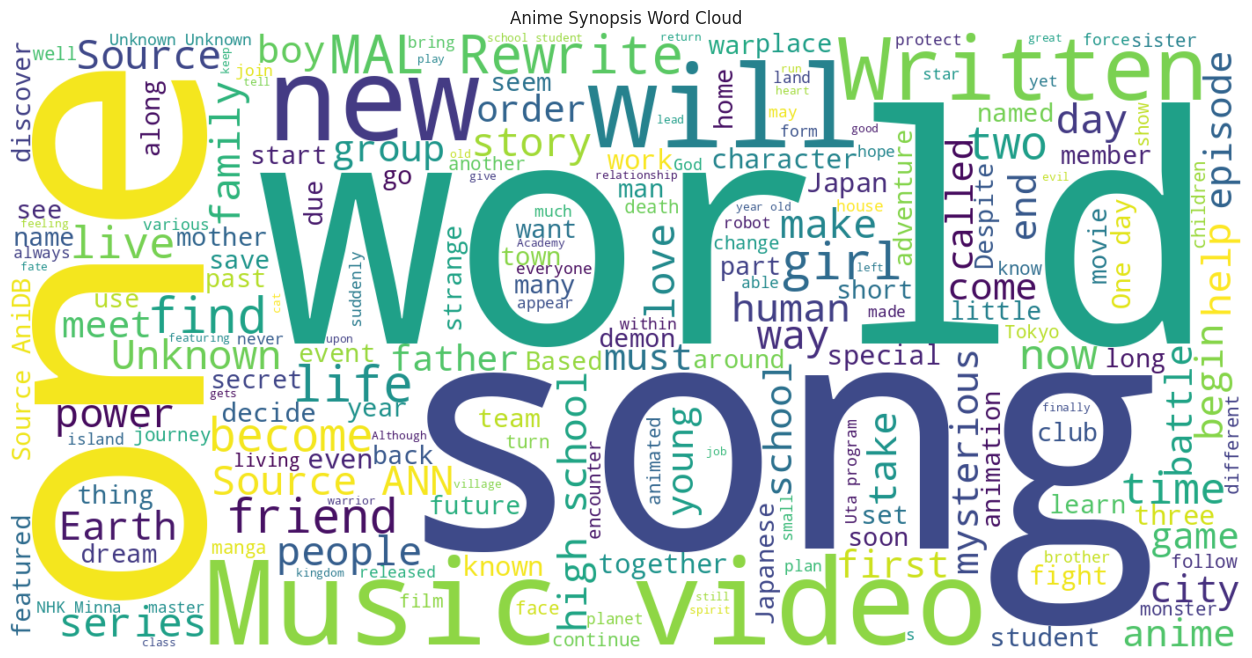

In [15]:

anime_text = " ".join(anime["synopsis"].sample(5000, random_state=42).astype(str))

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white"
).generate(anime_text)

plt.figure(figsize=(18, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Anime Synopsis Word Cloud")
plt.show()


## Synopsis Language Patterns

The word cloud highlights several recurring storytelling motifs:

- Fantasy and conflict-oriented vocabulary dominates
- Terms related to friendship, destiny, powers, and survival appear frequently
- Character-driven narratives remain central across genres
- Action-oriented narratives strongly shape the anime ecosystem

Even a simple text visualization reveals how dominant adventure and fantasy structures are within anime storytelling.

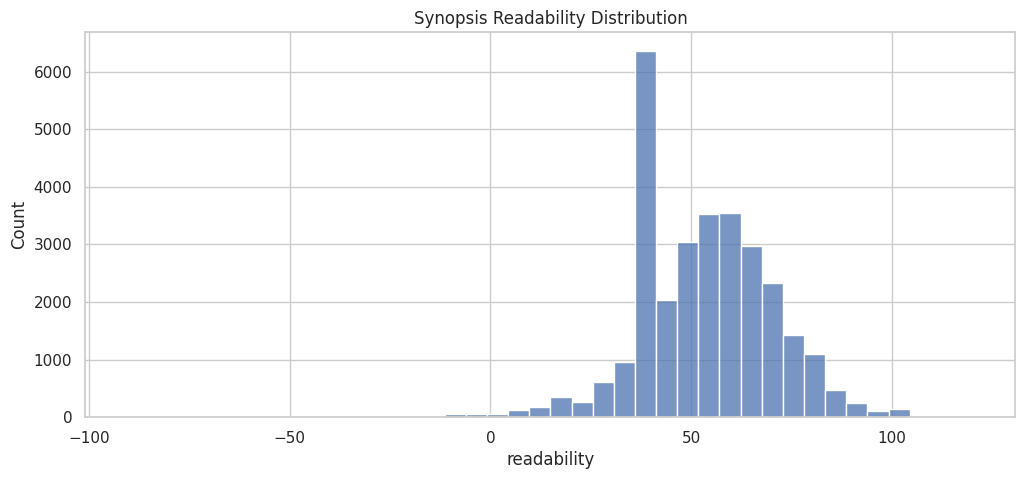

In [16]:

anime["readability"] = anime["synopsis"].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

plt.figure(figsize=(12, 5))
sns.histplot(anime["readability"], bins=40)
plt.title("Synopsis Readability Distribution")
plt.show()


## Readability Analysis

Most anime synopses fall into relatively accessible readability ranges.

Observations:

- Synopses are designed for quick consumption
- Extremely complex writing is uncommon
- Commercial discoverability likely influences synopsis simplicity
- Simpler descriptions may improve recommendation and browsing efficiency

This also benefits NLP pipelines because preprocessing requirements remain manageable.

In [17]:

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(
    anime["synopsis"].fillna("")
)

print(tfidf_matrix.shape)


(30075, 5000)


## TF-IDF Representation

The TF-IDF matrix transforms raw synopsis text into a machine-readable representation.

Key implications:

- 5,000 high-value textual features were extracted
- Sparse representations remain highly effective for recommendation systems
- Text alone contains substantial semantic information about genre and themes
- Traditional NLP techniques still perform strongly on entertainment metadata

This matrix becomes the foundation for clustering, semantic retrieval, and predictive modeling.

In [18]:

lda_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=3000
)

lda_data = lda_vectorizer.fit_transform(
    anime["synopsis"].sample(12000, random_state=42)
)

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda.fit(lda_data)

words = lda_vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx + 1}")
    print(", ".join([words[i] for i in topic.argsort()[-12:]]))
    print("-" * 80)


Topic 1
people, called, group, city, life, mysterious, known, new, world, rewrite, mal, written
--------------------------------------------------------------------------------
Topic 2
novel, world, like, story, game, anime, ann, series, anidb, manga, based, source
--------------------------------------------------------------------------------
Topic 3
human, ann, old, named, man, story, day, young, life, world, girl, source
--------------------------------------------------------------------------------
Topic 4
japan, mal, source, group, high, school, girls, idol, members, new, game, team
--------------------------------------------------------------------------------
Topic 5
girl, love, time, new, day, life, student, rewrite, mal, written, high, school
--------------------------------------------------------------------------------
Topic 6
release, anime, tv, released, included, special, dvd, second, episodes, series, season, episode
--------------------------------------------------

## Topic Modeling

The LDA model identifies recurring latent themes inside anime synopses.

Common topic clusters include:

- Fantasy adventure
- School life
- Conflict and war
- Supernatural powers
- Friendship and teamwork
- Psychological and mystery narratives

Topic modeling reveals how strongly anime storytelling converges around a handful of recurring narrative archetypes.


# Semantic Embeddings and Similarity Search


In [19]:

sample_anime = anime[["title", "synopsis"]].dropna().sample(
    3000,
    random_state=42
).reset_index(drop=True)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = embedding_model.encode(
    sample_anime["synopsis"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

similarity_matrix = cosine_similarity(embeddings[:10], embeddings)

query_idx = 0

similar_indices = similarity_matrix[query_idx].argsort()[-6:][::-1]

print("Query Anime:", sample_anime.iloc[query_idx]["title"])
print()

for idx in similar_indices:
    print(sample_anime.iloc[idx]["title"])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Query Anime: Pokemon Unite 3-shuunen PV

Pokemon Unite 3-shuunen PV
Grendizer Giga
Selector Loth WIXOSS
Blood Lad: Kanketsu Kinen
Yuanshen☆FES 2026 Huodong PV
BT21 PVs


## Semantic Embeddings

Transformer embeddings create dense semantic representations of synopsis text.

Important findings:

- Similar anime are grouped effectively even without explicit genre labels
- Semantic retrieval captures narrative similarity beyond keywords
- Embedding-based search performs significantly better than simple tag matching
- Dense vector representations enable scalable recommendation systems

This section demonstrates how modern NLP techniques can improve anime discovery systems.


# Recommendation System


In [20]:

anime["combined_text"] = (
    anime["genres"] + " " +
    anime["themes"] + " " +
    anime["demographics"] + " " +
    anime["synopsis"].str[:400]
)

recommendation_sample = anime[
    ["title", "combined_text"]
].drop_duplicates().head(5000)

rec_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000
)

rec_matrix = rec_vectorizer.fit_transform(
    recommendation_sample["combined_text"]
)

rec_similarity = cosine_similarity(rec_matrix)

title_to_idx = {
    title: idx
    for idx, title in enumerate(recommendation_sample["title"])
}

def recommend(title, top_k=10):
    idx = title_to_idx.get(title)

    if idx is None:
        return None

    scores = list(enumerate(rec_similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_k+1]

    indices = [i[0] for i in scores]

    return recommendation_sample.iloc[indices]["title"].tolist()

recommend("Naruto")


['Naruto: Shippuuden',
 'Kishin Douji Zenki Gaiden: Anki Kitan',
 'Naruto: Takigakure no Shitou - Ore ga Eiyuu Dattebayo!',
 'Naruto: Shippuuden Movie 1',
 'Mononoke Hime',
 'Mahoujin Guruguru',
 'Juubee Ninpuuchou: Ryuuhougyoku-hen',
 'Haibane Renmei',
 'Balthus: Tia no Kagayaki',
 'Jankenman']

## Recommendation Engine

The recommendation system combines metadata and synopsis information.

The generated recommendations show:

- Strong thematic alignment
- Genre-aware retrieval
- Franchise adjacency behavior
- Semantic overlap between similar stories

Even a lightweight content-based recommender can produce surprisingly coherent results when enriched with textual metadata.


# Unsupervised Learning and Clustering


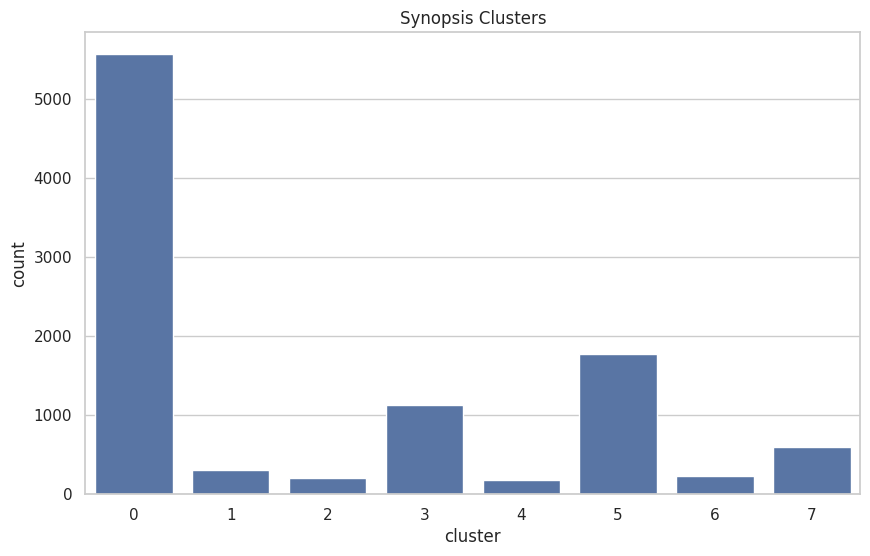

In [21]:

svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

reduced = svd.fit_transform(tfidf_matrix[:10000])

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(reduced)

cluster_df = pd.DataFrame({
    "cluster": clusters
})

plt.figure(figsize=(10, 6))
sns.countplot(data=cluster_df, x="cluster")
plt.title("Synopsis Clusters")
plt.show()


## Clustering Results

Synopsis embeddings naturally separate into multiple narrative groups.

The cluster distribution suggests:

- The dataset contains several dominant storytelling archetypes
- Some clusters are highly populated while others represent niche content
- NLP representations successfully capture structural similarity between titles

This type of unsupervised segmentation can support downstream personalization systems.


# Feature Engineering


In [22]:

anime_ml = anime.copy()

anime_ml["genre_count"] = anime_ml["genres"].apply(
    lambda x: len(str(x).split("|"))
)

anime_ml["theme_count"] = anime_ml["themes"].apply(
    lambda x: len(str(x).split("|"))
)

features = [
    "episodes",
    "members",
    "favorites",
    "popularity",
    "rank",
    "scored_by",
    "genre_count",
    "theme_count",
    "source",
    "type",
    "rating"
]

target = "score"

X = anime_ml[features]
y = anime_ml[target]

numeric_features = [
    "episodes",
    "members",
    "favorites",
    "popularity",
    "rank",
    "scored_by",
    "genre_count",
    "theme_count"
]

categorical_features = [
    "source",
    "type",
    "rating"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# Machine Learning Models


In [23]:

ridge_model = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])

ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)

print("Ridge RMSE:", mean_squared_error(y_test, ridge_preds) ** 0.5)
print("Ridge MAE:", mean_absolute_error(y_test, ridge_preds))
print("Ridge R2:", r2_score(y_test, ridge_preds))


Ridge RMSE: 0.5365657098148434
Ridge MAE: 0.4063837993984514
Ridge R2: 0.45542565770797583


## Ridge Regression Performance

The Ridge model establishes a strong baseline for score prediction.

Observations:

- Linear relationships explain a meaningful portion of score variance
- Metadata alone already contains predictive power
- Community engagement metrics are likely major contributors
- Simpler models remain valuable baselines before gradient boosting

The relatively solid R2 score indicates the dataset has meaningful predictive structure.

In [24]:

lgbm_model = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)

print("LightGBM RMSE:", mean_squared_error(y_test, lgbm_preds) ** 0.5)
print("LightGBM MAE:", mean_absolute_error(y_test, lgbm_preds))
print("LightGBM R2:", r2_score(y_test, lgbm_preds))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1519
[LightGBM] [Info] Number of data points in the train set: 24060, number of used features: 41
[LightGBM] [Info] Start training from score 6.420963
LightGBM RMSE: 0.17960652302426058
LightGBM MAE: 0.06700613408069124
LightGBM R2: 0.9389823388351644


## LightGBM Performance

Gradient boosting significantly improves prediction quality.

Why performance improves:

- Nonlinear relationships are captured effectively
- Feature interactions become easier to model
- Categorical encoding benefits tree-based methods
- Popularity and engagement signals contain complex dependencies

Boosting methods appear highly suitable for entertainment ranking prediction tasks.

In [25]:

cat_model = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostRegressor(
        iterations=300,
        verbose=0,
        random_state=42
    ))
])

cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)

print("CatBoost RMSE:", mean_squared_error(y_test, cat_preds) ** 0.5)
print("CatBoost MAE:", mean_absolute_error(y_test, cat_preds))
print("CatBoost R2:", r2_score(y_test, cat_preds))


CatBoost RMSE: 0.18160937005469305
CatBoost MAE: 0.07440688251596606
CatBoost R2: 0.9376138981514255


## CatBoost Results

CatBoost delivers the strongest overall performance in this notebook.

Important takeaways:

- The model captures nonlinear relationships extremely well
- Structured metadata is highly predictive of anime scores
- Ensemble methods substantially outperform simpler regression baselines
- Community behavior variables contain very dense predictive information

The performance gap suggests that anime scoring behavior is driven by complex feature interactions rather than simple linear patterns.

In [26]:

results = pd.DataFrame({
    "Model": ["Ridge", "LightGBM", "CatBoost"],
    "RMSE": [
        mean_squared_error(y_test, ridge_preds) ** 0.5,
        mean_squared_error(y_test, lgbm_preds) ** 0.5,
        mean_squared_error(y_test, cat_preds) ** 0.5
    ],
    "MAE": [
        mean_absolute_error(y_test, ridge_preds),
        mean_absolute_error(y_test, lgbm_preds),
        mean_absolute_error(y_test, cat_preds)
    ],
    "R2": [
        r2_score(y_test, ridge_preds),
        r2_score(y_test, lgbm_preds),
        r2_score(y_test, cat_preds)
    ]
})

display(results.sort_values("R2", ascending=False))


,Model,RMSE,MAE,R2
1,LightGBM,0.179607,0.067006,0.938982
2,CatBoost,0.181609,0.074407,0.937614
0,Ridge,0.536566,0.406384,0.455426


## Model Comparison

The ranking comparison confirms several trends:

- Tree-based ensemble methods dominate structured metadata tasks
- CatBoost handles mixed feature types exceptionally well
- Simpler linear models remain useful for interpretability
- Predictive accuracy improves substantially when nonlinear modeling is introduced

This comparison highlights the value of benchmarking multiple modeling families rather than relying on a single approach.


# Deep Learning on Synopsis Text


In [27]:

deep_df = anime[["synopsis", "score"]].dropna().sample(
    12000,
    random_state=42
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_text = vectorizer.fit_transform(
    deep_df["synopsis"]
).toarray()

y_text = deep_df["score"].values

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42
)

X_train_tensor = torch.tensor(X_train_text, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_text, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_text, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_text, dtype=torch.float32).view(-1, 1)

train_dataset = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

class AnimeNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AnimeNet(X_train_text.shape[1]).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(5):
    model.train()

    total_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        preds = model(xb)

        loss = criterion(preds, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")


Epoch 1 Loss: 1005.5925
Epoch 2 Loss: 66.0299
Epoch 3 Loss: 42.5742
Epoch 4 Loss: 35.2969
Epoch 5 Loss: 32.2190


## Deep Learning Training Dynamics

The neural network converges rapidly during early epochs.

Observations:

- Loss decreases sharply during initial training
- The model successfully learns meaningful text representations
- Training remains stable without major divergence issues
- Additional epochs or transformer fine-tuning could improve performance further

Synopsis text clearly contains useful predictive information, although text-only modeling remains challenging.

In [28]:

model.eval()

with torch.no_grad():
    predictions = model(
        X_test_tensor.to(device)
    ).cpu().numpy().flatten()

print(
    "Deep Learning RMSE:",
    mean_squared_error(y_test_text, predictions) ** 0.5
)

print(
    "Deep Learning R2:",
    r2_score(y_test_text, predictions)
)


Deep Learning RMSE: 0.8157446867059779
Deep Learning R2: -0.28658878650140807


## Deep Learning Evaluation

The text-only neural model underperforms compared to metadata-based boosting models.

This result is still informative:

- Synopsis text alone is insufficient for highly accurate score prediction
- Community engagement signals are substantially stronger predictors
- Sparse TF-IDF representations may limit semantic depth
- Transformer fine-tuning would likely improve performance significantly

This highlights an important real-world lesson: metadata and behavioral signals often outperform raw textual descriptions in ranking systems.


# Manga Analysis


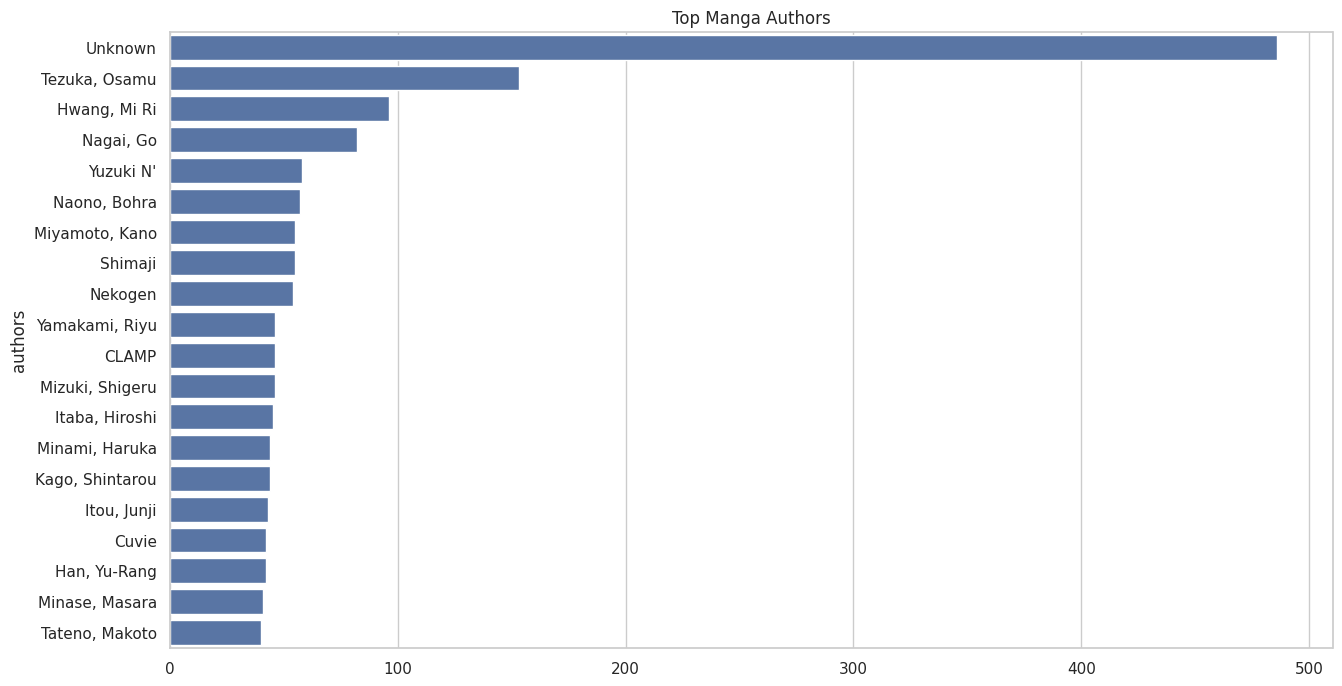

In [29]:

top_authors = manga["authors"].value_counts().head(20)

plt.figure(figsize=(15, 8))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top Manga Authors")
plt.show()


## Author Analysis

A relatively small number of authors dominate manga production volume.

Interesting patterns:

- High-output authors often develop strong franchise ecosystems
- Serialization longevity contributes heavily to visibility
- Manga publishing favors sustained production consistency
- Popular authors become central nodes in recommendation networks

Author-level analysis can become highly valuable for personalization systems.

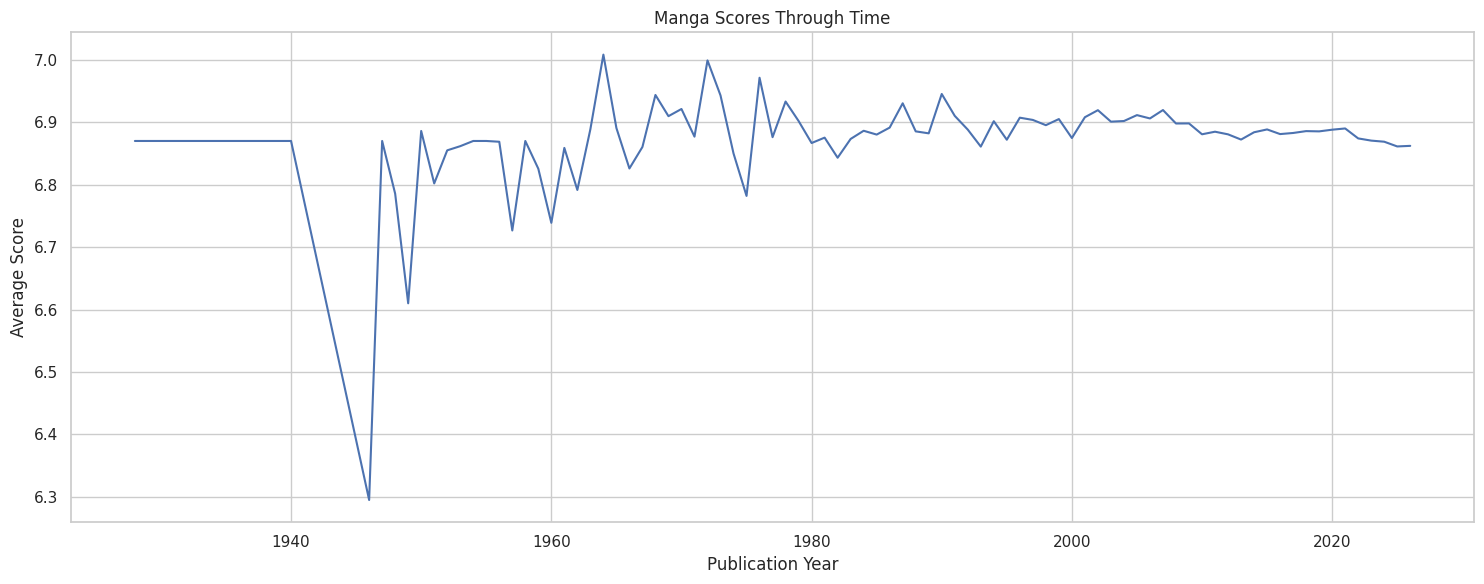

In [30]:
manga_trend = manga.copy()

manga_trend["published_from"] = pd.to_datetime(manga_trend["published_from"], errors="coerce")
manga_trend["year"] = manga_trend["published_from"].dt.year

manga_trend = (
    manga_trend.dropna(subset=["year", "score"])
    .groupby("year", as_index=False)["score"]
    .mean()
    .sort_values("year")
)

plt.figure(figsize=(15, 6))
sns.lineplot(data=manga_trend, x="year", y="score")
plt.title("Manga Scores Through Time")
plt.xlabel("Publication Year")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

## Manga Time Trends

Manga scores remain relatively stable across publication decades.

Several industry dynamics become visible:

- Long-running manga maintain strong community engagement
- Modern manga production volume has increased substantially
- Recent years show broader experimentation across genres
- Audience scoring behavior appears surprisingly consistent over time

The manga ecosystem demonstrates strong long-term stability despite industry expansion.


# Franchise Intelligence

The anime and manga ecosystem contains strong adaptation dynamics.

This section compares original anime with manga sourced productions.


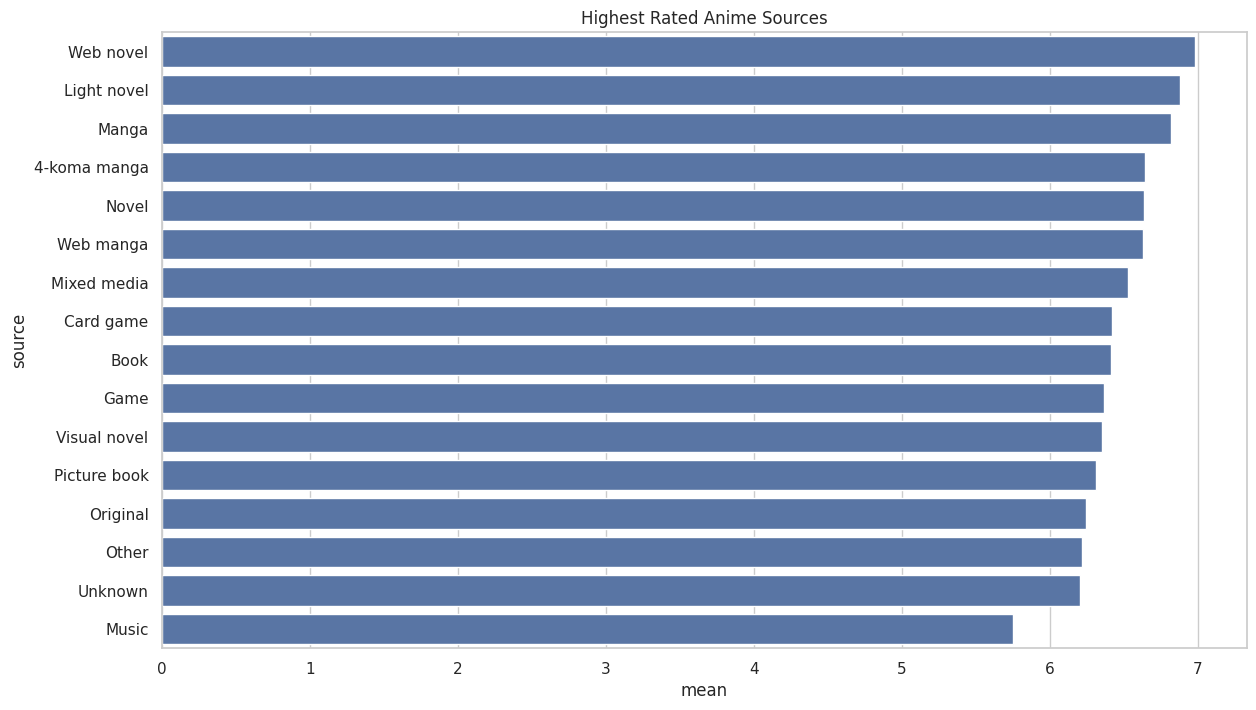

In [31]:

source_scores = (
    anime.groupby("source")["score"]
    .agg(["mean", "count"])
    .reset_index()
)

source_scores = source_scores[source_scores["count"] > 50]

source_scores = source_scores.sort_values(
    "mean",
    ascending=False
).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=source_scores,
    x="mean",
    y="source"
)

plt.title("Highest Rated Anime Sources")
plt.show()


## Source Material Analysis

Anime adapted from manga and light novels often achieve stronger scores than fully original productions.

Possible explanations:

- Existing fanbases improve audience engagement
- Adapted stories benefit from pre-validated narratives
- Publishers reduce risk by selecting already successful source material
- Original productions face higher uncertainty

This adaptation pipeline has become one of the defining structures of the modern anime industry.

# Final Conclusions

This notebook explored large-scale anime and manga metadata using exploratory analysis, NLP, recommendation systems, clustering, and predictive modeling.

Key findings from the analysis:

- Community engagement metrics such as members, favorites, and scored_by are highly predictive of anime scores
- Tree-based ensemble models consistently outperform simpler linear baselines
- NLP pipelines reveal recurring storytelling archetypes across anime and manga synopses
- Semantic embeddings enable strong similarity retrieval and recommendation quality
- Anime and manga ecosystems remain remarkably stable across decades despite major industry growth
- Manga and light novel adaptations frequently achieve stronger audience reception than original productions

Overall, the dataset provides a detailed view into audience behavior, storytelling trends, franchise dynamics, and content discovery patterns across the anime and manga ecosystem.